In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC


In [5]:
df_shop_smart = pd.read_csv("datasets/shop_smart.csv")

In [6]:
df_shop_smart.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
df_shop_smart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
# Duplicated values
df_shop_smart.duplicated().sum()

np.int64(125)

In [9]:
df_shop_smart[df_shop_smart.duplicated()]
# No need to remove cause under given features, records repetition could be natural

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12180,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,13,9,20,Returning_Visitor,False,False


In [10]:
# Inconsistent values
print(df_shop_smart["Month"].unique())
print(df_shop_smart["VisitorType"].unique())
# No inconsistency

['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning_Visitor' 'New_Visitor' 'Other']


In [11]:
# Split input and output
X = df_shop_smart.drop(columns=["Revenue"])
y = df_shop_smart["Revenue"]

In [12]:
# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [13]:
# Missing values
print(X_train.isnull().sum())
print(X_test.isnull().sum())
# No missing values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
dtype: int64
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
d

In [14]:
# Feature engineering
# Encoding

# Boolean to int conversion
X_train["Weekend"] = X_train["Weekend"].astype("int")
X_test["Weekend"] = X_test["Weekend"].astype("int")
y_train = y_train.astype("int")
y_test = y_test.astype("int")

In [15]:
# label(ordinal) encoding
oe = OrdinalEncoder(categories=[['Jan', 'Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']])
X_train["Month"] = oe.fit_transform(X_train[["Month"]])
X_test["Month"] = oe.transform(X_test[["Month"]])

In [16]:
# One hot encoding
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    drop="first"
).set_output(
    transform="pandas"
)
X_train_encoded = ohe.fit_transform(X_train[["VisitorType"]])
X_train = pd.concat([X_train.drop(columns=["VisitorType"]), X_train_encoded], axis=1)

X_test_encoded = ohe.fit_transform(X_test[["VisitorType"]])
X_test = pd.concat([X_test.drop(columns=["VisitorType"]), X_test_encoded], axis=1)

In [17]:
# Decision tree training - without pruning
dtc_model = DecisionTreeClassifier()
dtc_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
# Model Evaluation - testing data
y_test_pred = dtc_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.8588807785888077
Precision: 0.542713567839196
Recall: 0.5654450261780105
F1: 0.5538461538461539
[[1902  182]
 [ 166  216]]


In [19]:
# Model evaluation - testing data
y_train_pred = dtc_model.predict(X_train)

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
cm = confusion_matrix(y_train, y_train_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

# Model is strictly overfitted

Decision Tree Classifier:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
[[8338    0]
 [   0 1526]]


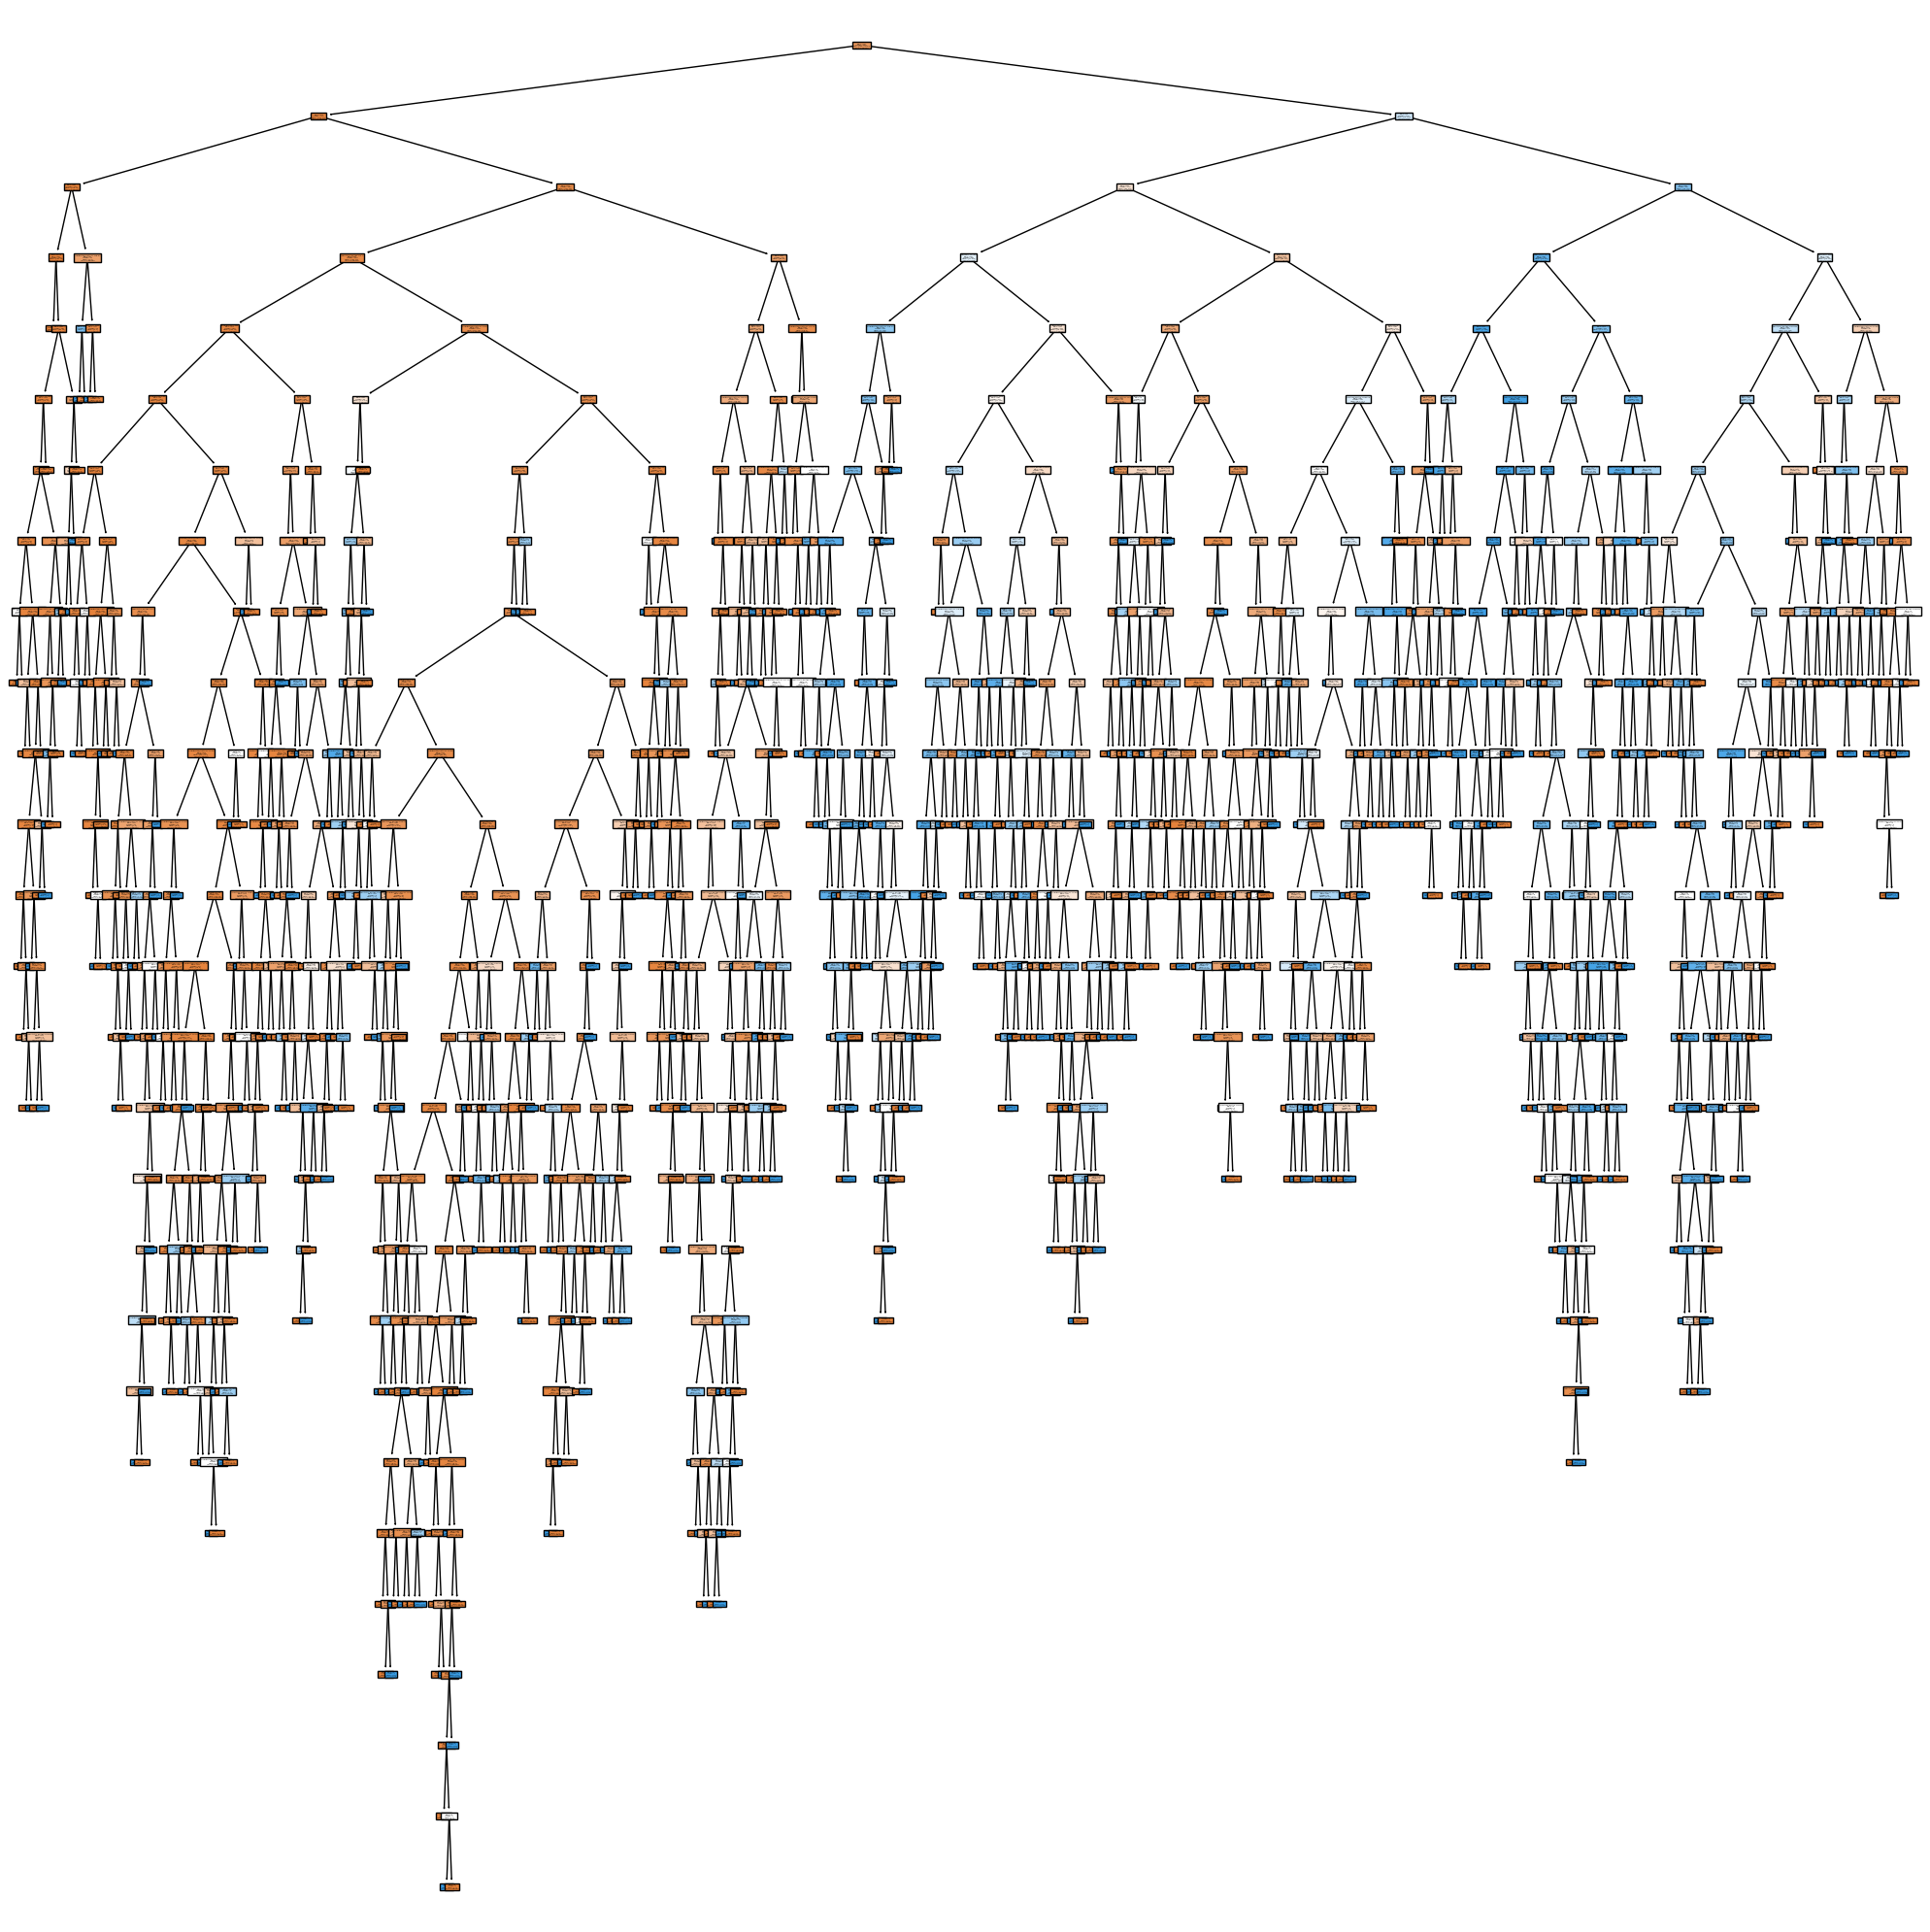

In [20]:
plt.figure(figsize=(20, 20))

plot_tree(
    dtc_model,
    feature_names=X_train.columns,
    class_names=["No purchase", "Purchase"],
    filled=True
)

plt.tight_layout()

In [21]:
# Decision tree training - with pruning
dtc_cv_pre_model = GridSearchCV(
    DecisionTreeClassifier(),
    {
        "max_depth": [3, 5, 7, 10, 15, 20],
        "min_samples_split": [2, 5, 10, 20, 50, 100],
        "min_samples_leaf": [1, 2, 5, 10, 20, 50],
        
    },
    cv=5,
    scoring="f1"
)

dtc_cv_pre_model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [22]:
# Model Evaluation - testing data
y_test_pred = dtc_cv_pre_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.8905109489051095
Precision: 0.6761006289308176
Recall: 0.56282722513089
F1: 0.6142857142857143
[[1981  103]
 [ 167  215]]


In [23]:
# Decision Tree Classifier - with post pruning
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

dtc_cv_post_model = GridSearchCV(
    DecisionTreeClassifier(),
    {
        "ccp_alpha": ccp_alphas
        
    },
    cv=5,
    scoring="f1"
)

dtc_cv_post_model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,{'ccp_alpha': array([0.0000...46325788e-02])}
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [24]:
# Model Evaluation - testing data
y_test_pred = dtc_cv_post_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.897404703974047
Precision: 0.6776859504132231
Recall: 0.643979057591623
F1: 0.6604026845637584
[[1967  117]
 [ 136  246]]


In [25]:
# Decision tree classifier - with best pruning(pre & post) parameter values
# Best value of params
print(dtc_cv_pre_model.best_params_)
print(dtc_cv_post_model.best_params_)

{'max_depth': 10, 'min_samples_leaf': 50, 'min_samples_split': 20}
{'ccp_alpha': np.float64(0.0008638140895271089)}


In [26]:
# Decision tree training - with pre and post pruning
dtc_model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=50,
    min_samples_leaf=2,
    ccp_alpha=0.0009637651000981781
)
dtc_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,50
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
# Model Evaluation - testing data
y_test_pred = dtc_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.897404703974047
Precision: 0.6776859504132231
Recall: 0.643979057591623
F1: 0.6604026845637584
[[1967  117]
 [ 136  246]]


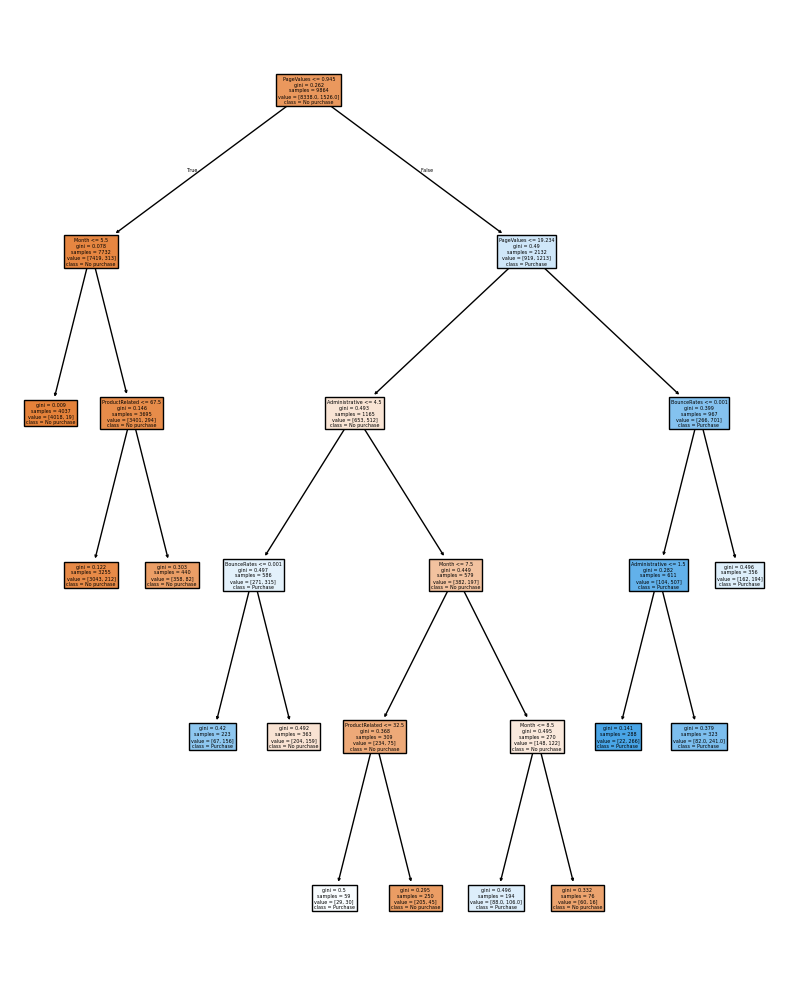

In [28]:
plt.figure(figsize=(8, 10))

plot_tree(
    dtc_model,
    feature_names=X_train.columns,
    class_names=["No purchase", "Purchase"],
    filled=True
)

plt.tight_layout()